<a href="https://colab.research.google.com/github/algaalex/Gaussian-Processes-GANs-GNNs/blob/main/04_quickdraw_dcgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2.3 — QuickDraw Birthday-Cake DCGAN

This notebook downloads the official 28x28 NumPy bitmap file for the
`birthday cake` category, explores the sketches, trains a DCGAN, plots training
progress, compares real and generated sketches, and calculates FID.



In [1]:
import sys
import subprocess

try:
    from torchmetrics.image.fid import FrechetInceptionDistance
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "torchmetrics[image]>=1.3",
            "torch-fidelity>=0.3.0",
        ]
    )



In [2]:
import json
import random
import urllib.parse
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision.transforms.functional as TF
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision.utils import make_grid
from tqdm.auto import tqdm



In [3]:
# ----------------------------- Configuration -----------------------------
QUICK_RUN = False
CATEGORY = "birthday cake"  # Change to "cat" or "house" for the optional extension.
SEED = 42
IMAGE_SIZE = 32
LATENT_DIM = 100
BATCH_SIZE = 256
EPOCHS = 2 if QUICK_RUN else 30
LEARNING_RATE = 2e-4
MAX_TRAIN_SAMPLES = 10_000 if QUICK_RUN else 50_000
FID_SAMPLES = 1_000 if QUICK_RUN else 5_000
DATA_DIR = Path("data/quickdraw")
OUTPUT_DIR = Path("outputs/quickdraw") / CATEGORY.replace(" ", "_")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
print(f"Using device: {DEVICE}")


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()



Using device: cuda


## 1. Download and explore the official QuickDraw bitmap data



Loaded 144,982 'birthday cake' drawings with shape (144982, 784)
Drawings used for GAN training: 50,000


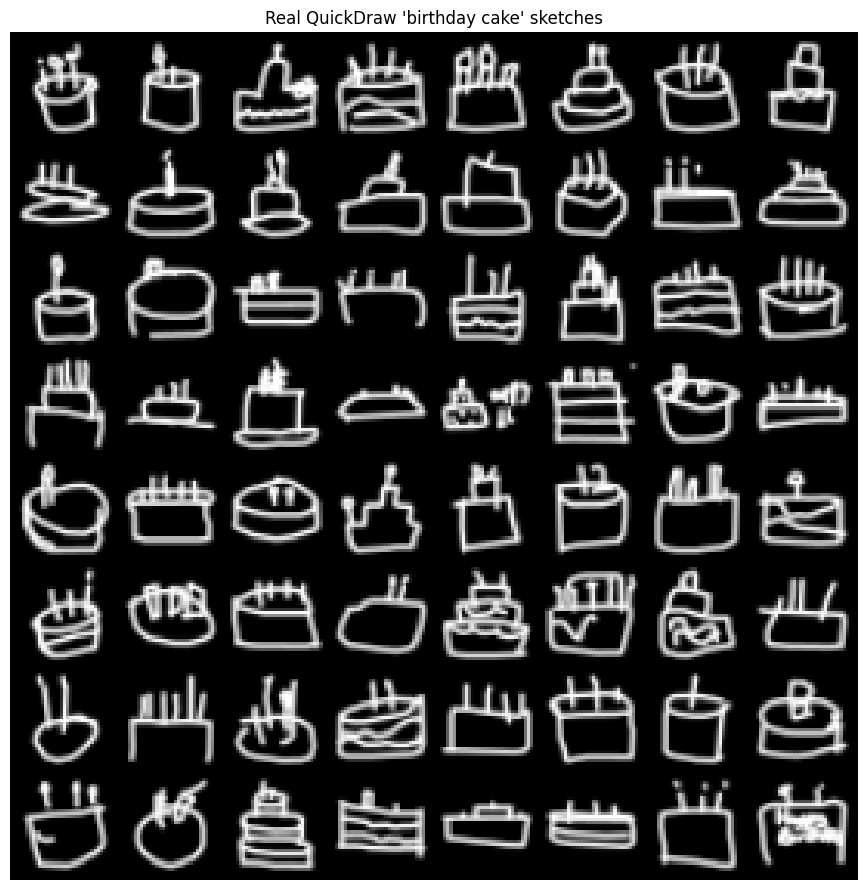

In [4]:
def download_quickdraw_category(category: str, destination_directory: Path = DATA_DIR) -> Path:
    destination_directory.mkdir(parents=True, exist_ok=True)
    safe_filename = category.replace(" ", "_") + ".npy"
    destination = destination_directory / safe_filename
    if destination.exists():
        return destination

    encoded_category = urllib.parse.quote(category, safe="")
    url = (
        "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
        f"{encoded_category}.npy"
    )
    print(f"Downloading QuickDraw category: {category}")
    try:
        urllib.request.urlretrieve(url, destination)
    except Exception:
        destination.unlink(missing_ok=True)
        raise
    return destination


bitmap_path = download_quickdraw_category(CATEGORY)
all_bitmaps = np.load(bitmap_path, mmap_mode="r")
if all_bitmaps.ndim != 2 or all_bitmaps.shape[1] != 28 * 28:
    raise ValueError(f"Unexpected bitmap array shape: {all_bitmaps.shape}")
print(f"Loaded {len(all_bitmaps):,} '{CATEGORY}' drawings with shape {all_bitmaps.shape}")

rng = np.random.default_rng(SEED)
selected_indices = rng.choice(
    len(all_bitmaps),
    size=min(MAX_TRAIN_SAMPLES, len(all_bitmaps)),
    replace=False,
)


class QuickDrawBitmapDataset(Dataset):
    def __init__(self, bitmaps: np.ndarray, indices: np.ndarray, image_size: int = IMAGE_SIZE):
        self.bitmaps = bitmaps
        self.indices = np.asarray(indices)
        self.image_size = image_size

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, item: int) -> torch.Tensor:
        # Copy avoids returning a non-writable memory-mapped NumPy view.
        image = np.array(self.bitmaps[self.indices[item]], copy=True).reshape(28, 28)
        tensor = torch.from_numpy(image).float().unsqueeze(0) / 255.0
        tensor = TF.resize(tensor, [self.image_size, self.image_size], antialias=True)
        return tensor * 2 - 1


train_dataset = QuickDrawBitmapDataset(all_bitmaps, selected_indices)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
print(f"Drawings used for GAN training: {len(train_dataset):,}")


def denormalise(images: torch.Tensor) -> torch.Tensor:
    return ((images.detach().cpu() + 1) / 2).clamp(0, 1)


def show_grid(images: torch.Tensor, title: str, path: Path, nrow: int = 8) -> None:
    grid = make_grid(denormalise(images), nrow=nrow, padding=2)
    plt.figure(figsize=(9, 9))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()


real_examples = torch.stack([train_dataset[index] for index in range(64)])
show_grid(real_examples, f"Real QuickDraw '{CATEGORY}' sketches", OUTPUT_DIR / "real_samples.png")



## 2. DCGAN architecture

A convolutional model is appropriate because local line segments and their
spatial arrangement form the sketch. The generator upsamples from 4x4 to
32x32, while the discriminator performs the reverse operation.



In [11]:
class SketchGenerator(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.network = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, noise: torch.Tensor) -> torch.Tensor:
        return self.network(noise)


class SketchDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        return self.network(images).view(-1)


def initialise_weights(module: nn.Module) -> None:
    classname = module.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0)


generator = SketchGenerator().to(DEVICE)
discriminator = SketchDiscriminator().to(DEVICE)
generator.apply(initialise_weights)
discriminator.apply(initialise_weights)
print(generator)
print(discriminator)



SketchGenerator(
  (network): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
SketchDiscriminator(
  (network): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, 

## 3. Train the DCGAN and record progress



Epoch 1/30:   0%|          | 0/195 [00:00<?, ?it/s]

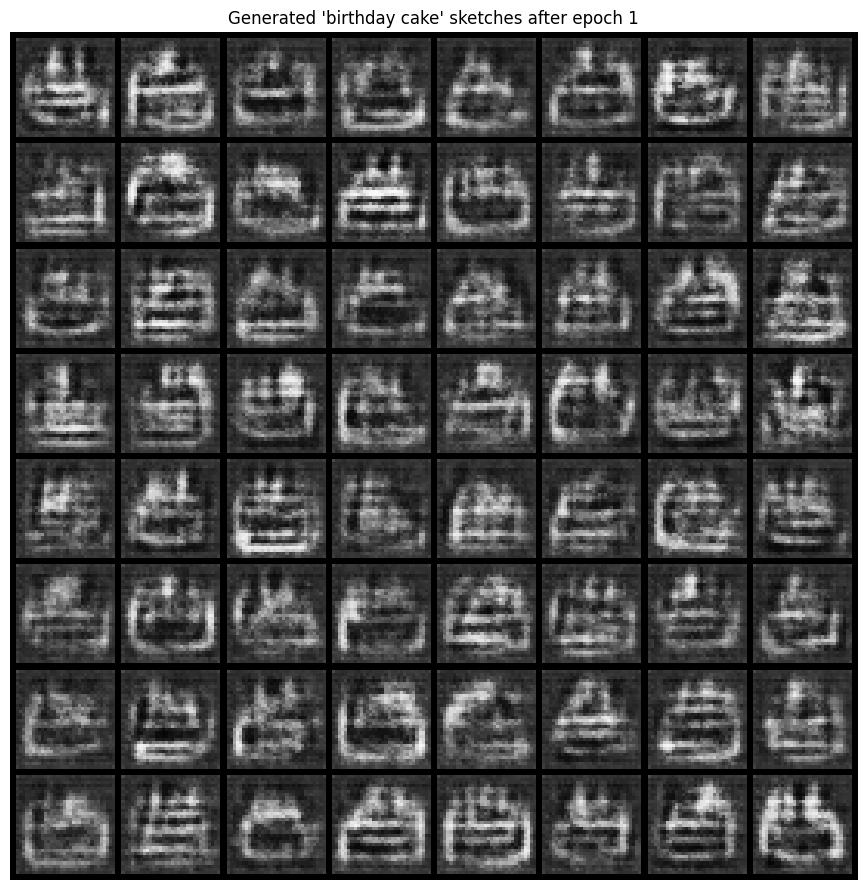

Epoch 2/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 3/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 4/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 5/30:   0%|          | 0/195 [00:00<?, ?it/s]

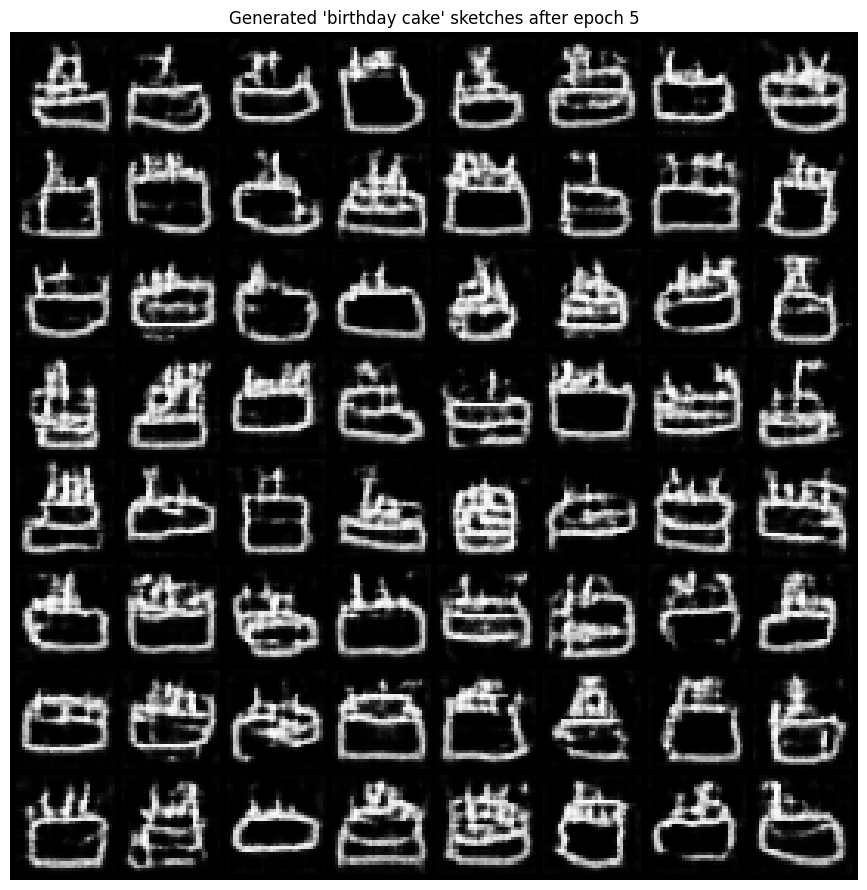

Epoch 6/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 7/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 8/30:   0%|          | 0/195 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb411520720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb411520720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 9/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 10/30:   0%|          | 0/195 [00:00<?, ?it/s]

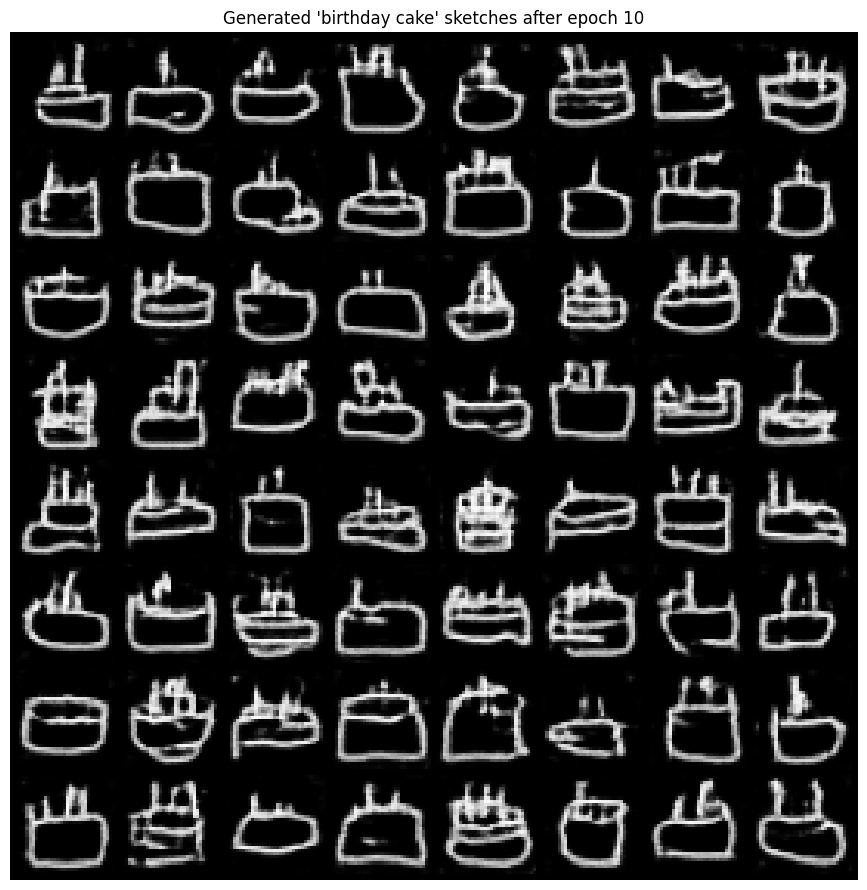

Epoch 11/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 12/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 13/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 14/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 15/30:   0%|          | 0/195 [00:00<?, ?it/s]

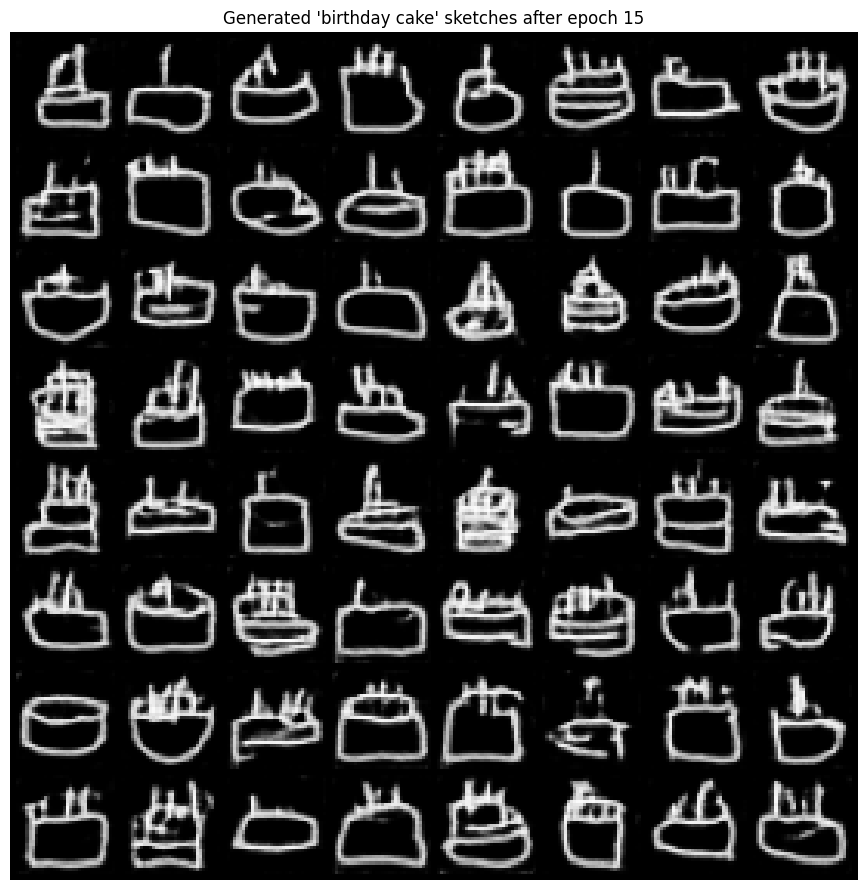

Epoch 16/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 17/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 18/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 19/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 20/30:   0%|          | 0/195 [00:00<?, ?it/s]

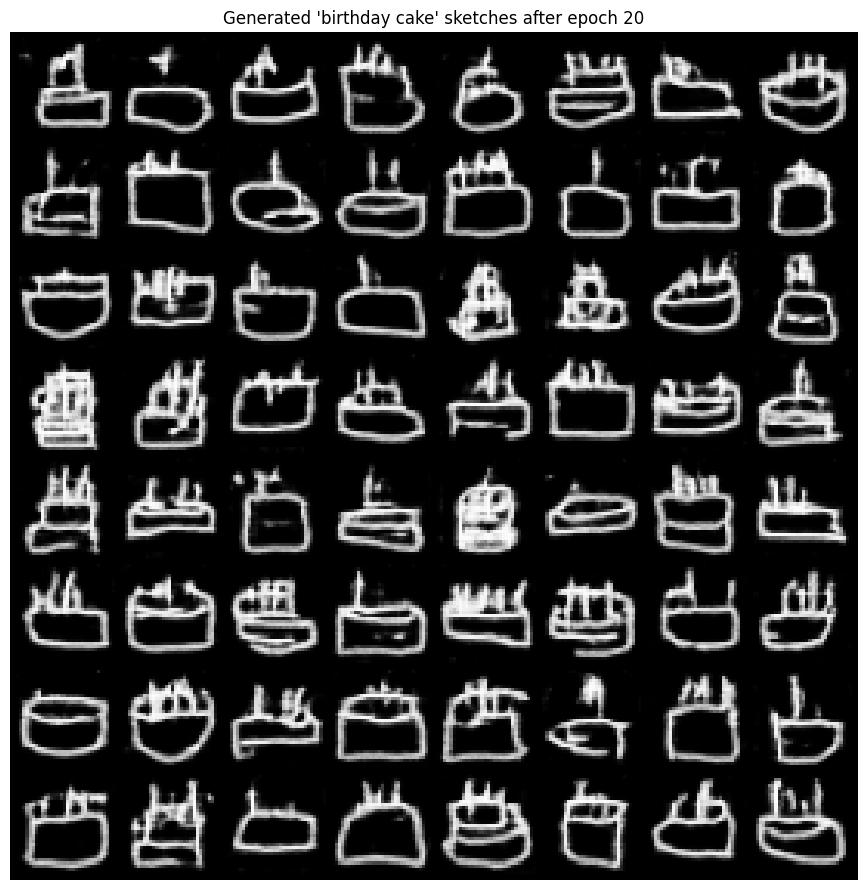

Epoch 21/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 22/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 23/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 24/30:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 25/30:   0%|          | 0/195 [00:00<?, ?it/s]

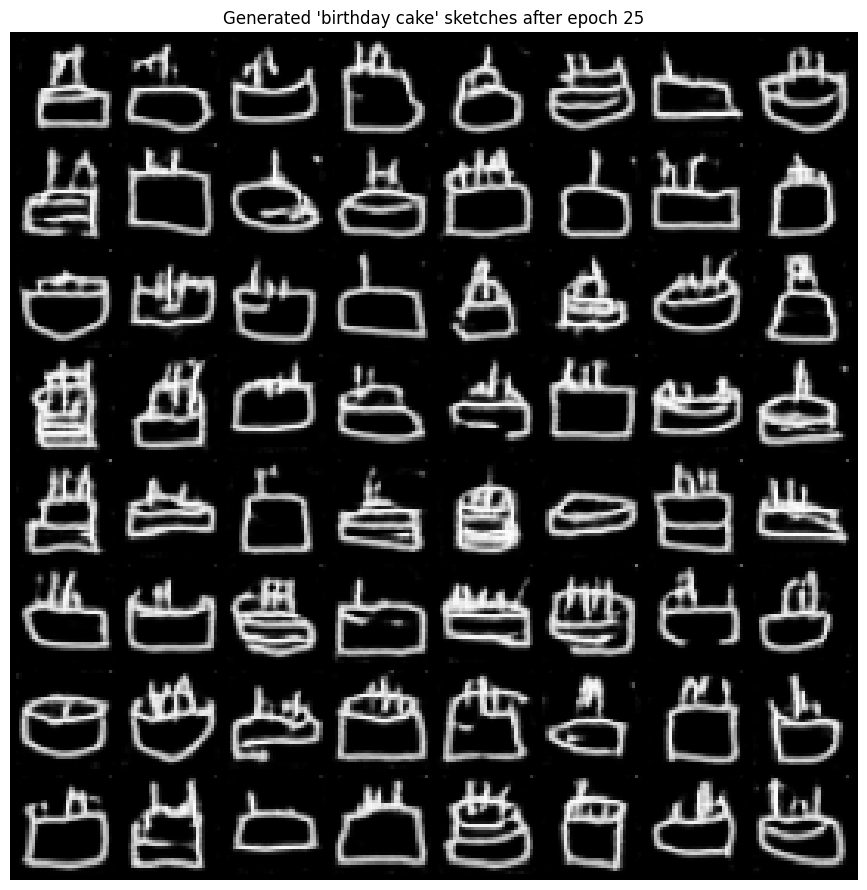

Epoch 26/30:   0%|          | 0/195 [00:00<?, ?it/s]

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimiser_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
optimiser_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=DEVICE)
generator_losses: list[float] = []
discriminator_losses: list[float] = []

for epoch in range(1, EPOCHS + 1):
    generator.train()
    discriminator.train()
    epoch_g, epoch_d = [], []
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for real_images in progress:
        real_images = real_images.to(DEVICE, non_blocking=True)
        count = real_images.size(0)

        optimiser_d.zero_grad(set_to_none=True)
        real_logits = discriminator(real_images)
        d_real = criterion(real_logits, torch.ones_like(real_logits))
        fake_images = generator(torch.randn(count, LATENT_DIM, 1, 1, device=DEVICE))
        fake_logits = discriminator(fake_images.detach())
        d_fake = criterion(fake_logits, torch.zeros_like(fake_logits))
        d_loss = 0.5 * (d_real + d_fake)
        d_loss.backward()
        optimiser_d.step()

        optimiser_g.zero_grad(set_to_none=True)
        generated_logits = discriminator(fake_images)
        g_loss = criterion(generated_logits, torch.ones_like(generated_logits))
        g_loss.backward()
        optimiser_g.step()

        epoch_g.append(float(g_loss.item()))
        epoch_d.append(float(d_loss.item()))
        progress.set_postfix(g=f"{g_loss.item():.3f}", d=f"{d_loss.item():.3f}")

    generator_losses.append(float(np.mean(epoch_g)))
    discriminator_losses.append(float(np.mean(epoch_d)))

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        generator.eval()
        with torch.no_grad():
            checkpoint_samples = generator(fixed_noise)
        show_grid(
            checkpoint_samples,
            f"Generated '{CATEGORY}' sketches after epoch {epoch}",
            OUTPUT_DIR / f"generated_epoch_{epoch:03d}.png",
        )



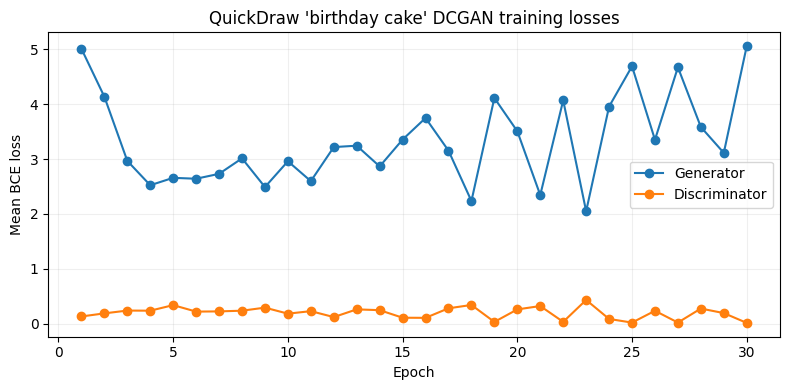

In [7]:
loss_table = pd.DataFrame(
    {
        "epoch": range(1, EPOCHS + 1),
        "generator_loss": generator_losses,
        "discriminator_loss": discriminator_losses,
    }
)
loss_table.to_csv(OUTPUT_DIR / "training_losses.csv", index=False)

plt.figure(figsize=(8, 4))
plt.plot(loss_table["epoch"], loss_table["generator_loss"], marker="o", label="Generator")
plt.plot(loss_table["epoch"], loss_table["discriminator_loss"], marker="o", label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Mean BCE loss")
plt.title(f"QuickDraw '{CATEGORY}' DCGAN training losses")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curves.png", dpi=220, bbox_inches="tight")
plt.show()



## 4. Real-versus-generated sketches



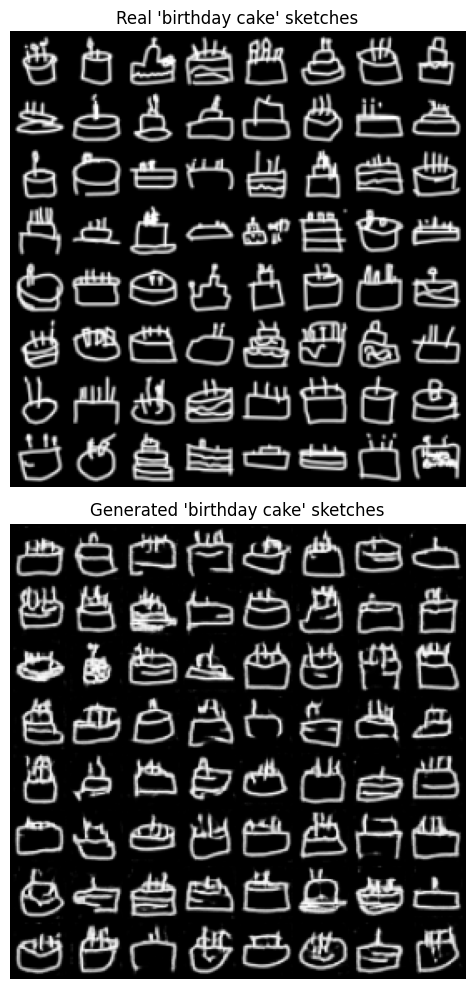

In [8]:
generator.eval()
with torch.no_grad():
    final_generated = generator(torch.randn(64, LATENT_DIM, 1, 1, device=DEVICE)).cpu()

fig, axes = plt.subplots(2, 1, figsize=(11, 10))
for axis, images, title in zip(
    axes,
    (real_examples, final_generated),
    (f"Real '{CATEGORY}' sketches", f"Generated '{CATEGORY}' sketches"),
):
    grid = make_grid(denormalise(images), nrow=8, padding=2)
    axis.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "real_vs_generated.png", dpi=220, bbox_inches="tight")
plt.show()



## 5. Fréchet Inception Distance (FID)

Grayscale sketches are repeated across three channels because the Inception
network expects RGB input. Both real and fake images use the same conversion.
FID should be interpreted together with the image grids because ImageNet
features were not designed specifically for sparse 28x28 line drawings.



In [9]:
@torch.no_grad()
def calculate_fid(number_of_samples: int = FID_SAMPLES) -> float:
    metric = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE)
    evaluation_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )
    seen = 0
    generator.eval()
    for real_images in tqdm(evaluation_loader, desc="Calculating FID"):
        remaining = number_of_samples - seen
        if remaining <= 0:
            break
        real_images = real_images[:remaining].to(DEVICE)
        count = real_images.size(0)
        fake_images = generator(torch.randn(count, LATENT_DIM, 1, 1, device=DEVICE))
        real_rgb = ((real_images + 1) / 2).clamp(0, 1).repeat(1, 3, 1, 1)
        fake_rgb = ((fake_images + 1) / 2).clamp(0, 1).repeat(1, 3, 1, 1)
        metric.update(real_rgb, real=True)
        metric.update(fake_rgb, real=False)
        seen += count
    return float(metric.compute().cpu().item())


fid_score = calculate_fid(min(FID_SAMPLES, len(train_dataset)))
print(f"QuickDraw '{CATEGORY}' FID ({min(FID_SAMPLES, len(train_dataset))} samples): {fid_score:.3f}")

metrics = {
    "category": CATEGORY,
    "fid": fid_score,
    "fid_samples": min(FID_SAMPLES, len(train_dataset)),
    "epochs": EPOCHS,
    "training_samples": len(train_dataset),
    "final_generator_loss": generator_losses[-1],
    "final_discriminator_loss": discriminator_losses[-1],
    "quick_run": QUICK_RUN,
    "seed": SEED,
}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))
torch.save(generator.state_dict(), OUTPUT_DIR / f"{CATEGORY.replace(' ', '_')}_generator.pt")
torch.save(discriminator.state_dict(), OUTPUT_DIR / f"{CATEGORY.replace(' ', '_')}_discriminator.pt")



Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 246MB/s]


Calculating FID:   0%|          | 0/391 [00:00<?, ?it/s]

QuickDraw 'birthday cake' FID (5000 samples): 19.397


In [10]:
print(f"Part 2.3 complete. Outputs saved to {OUTPUT_DIR.resolve()}")



Part 2.3 complete. Outputs saved to /content/outputs/quickdraw/birthday_cake
